<a href="https://colab.research.google.com/github/kittimaxz/Study/blob/main/time_series_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [2]:
# 1. Import data (using the direct URL link) and set index to the date column.
# parse_dates=True ensures the index is treated as datetime objects.
df = pd.read_csv(
    'https://raw.githubusercontent.com/freeCodeCamp/boilerplate-page-view-time-series-visualizer/main/fcc-forum-pageviews.csv',
    parse_dates=['date'],
    index_col='date'
)
df

,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933
...,...
2019-11-29,171584
2019-11-30,141161
2019-12-01,142918


In [3]:
# 2. Clean data by filtering out days in the top 2.5% and bottom 2.5% of the dataset.
df = df[
    (df['value'] >= df['value'].quantile(0.025)) &
    (df['value'] <= df['value'].quantile(0.975))
]
df

,value
date,
2016-05-19,19736
2016-05-26,18060
2016-05-27,19997
2016-05-28,19044
2016-05-29,20325
...,...
2019-11-24,138875
2019-11-29,171584
2019-11-30,141161


In [4]:
# 3. Create a draw_line_plot function
def draw_line_plot():
    # Draw line plot
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(df.index, df['value'], color='red', linewidth=1)

    # Set titles and labels
    ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
    ax.set_xlabel('Date')
    ax.set_ylabel('Page Views')

    # Save image and return fig (don't change this part)
    fig.savefig('line_plot.png')
    return fig

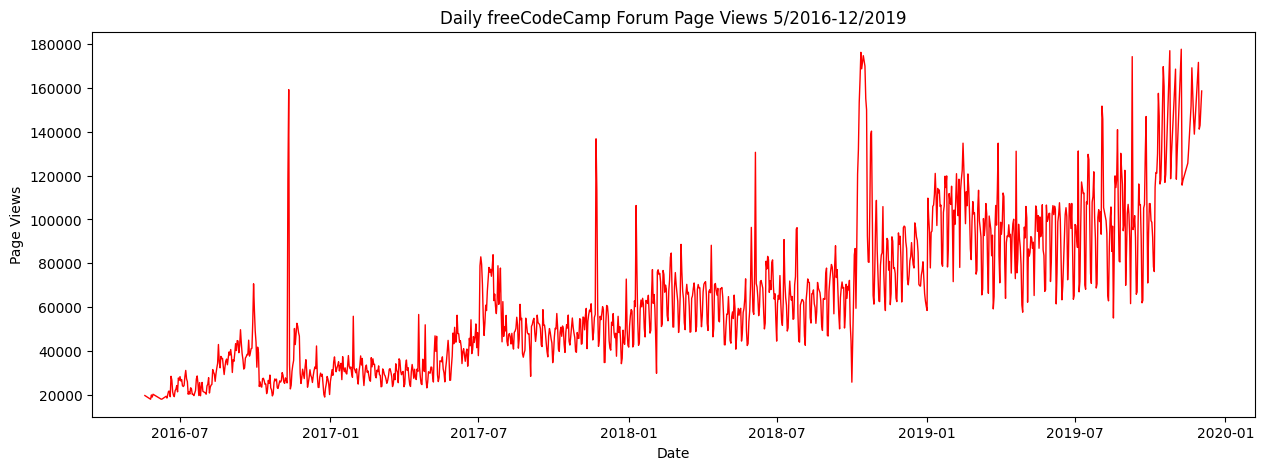

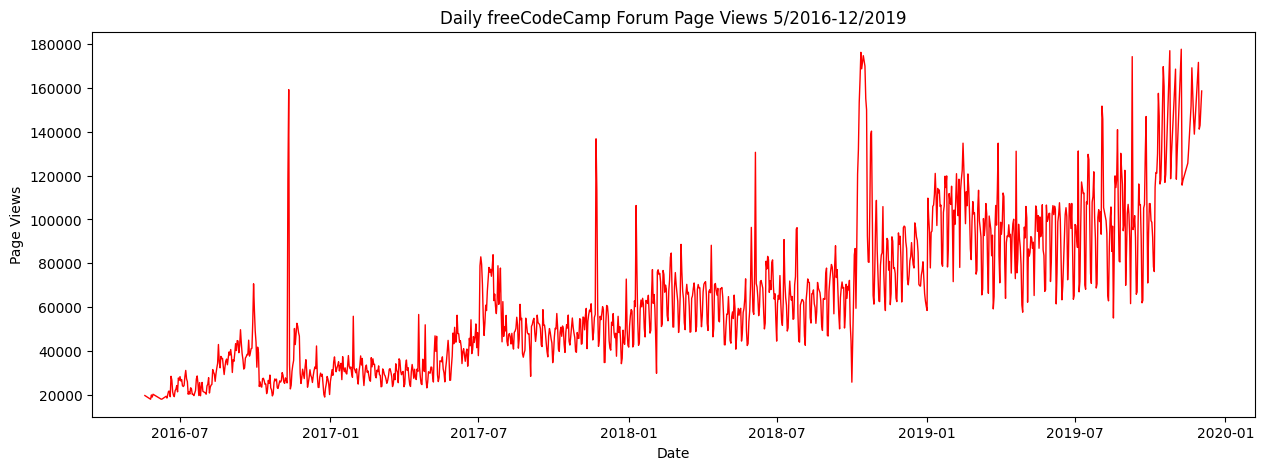

In [5]:
draw_line_plot()

In [6]:
# 4. Create a draw_bar_plot function
def draw_bar_plot():
    # Copy data and modify for monthly bar plot
    df_bar = df.copy()
    df_bar['year'] = df_bar.index.year
    df_bar['month'] = df_bar.index.strftime('%B')

    # Group data by year and month, calculating the mean page views
    df_pivot = df_bar.groupby(['year', 'month'])['value'].mean().unstack()

    # Reorder the month columns so they start at January and end at December
    months_order = [
        'January', 'February', 'March', 'April', 'May', 'June',
        'July', 'August', 'September', 'October', 'November', 'December'
    ]
    df_pivot = df_pivot.reindex(columns=months_order)

    # Draw bar plot
    fig = df_pivot.plot(kind='bar', figsize=(15, 7), xlabel='Years', ylabel='Average Page Views').get_figure()
    plt.legend(title='Months')

    # Save image and return fig (don't change this part)
    fig.savefig('bar_plot.png')
    return fig

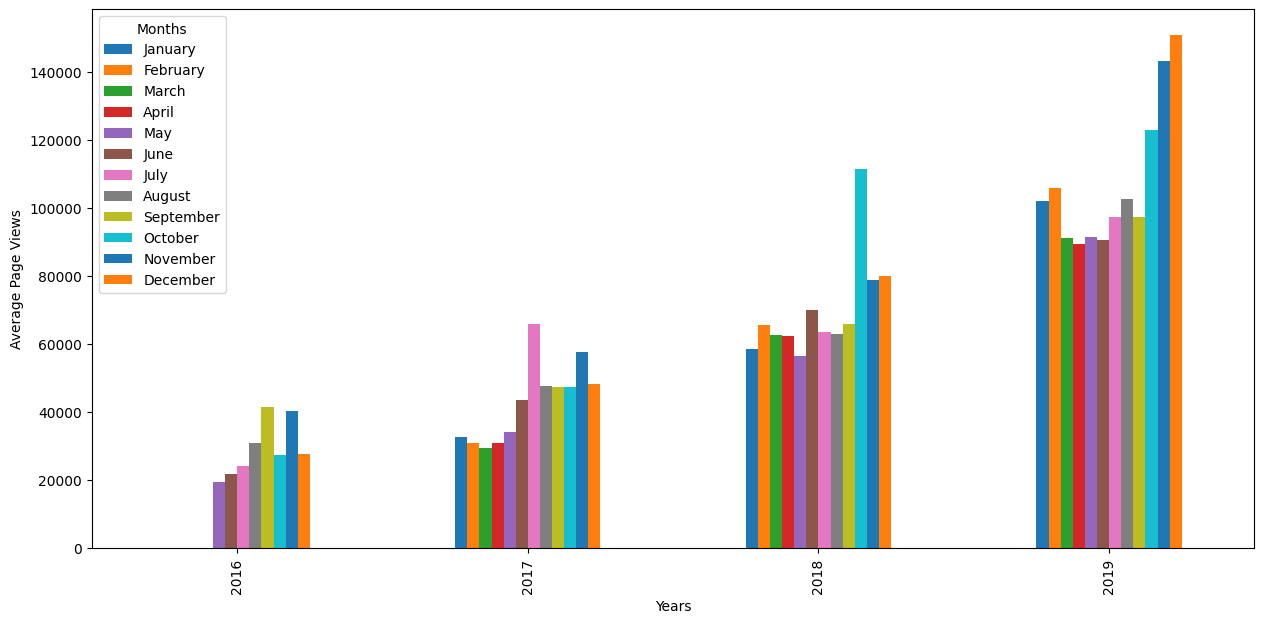

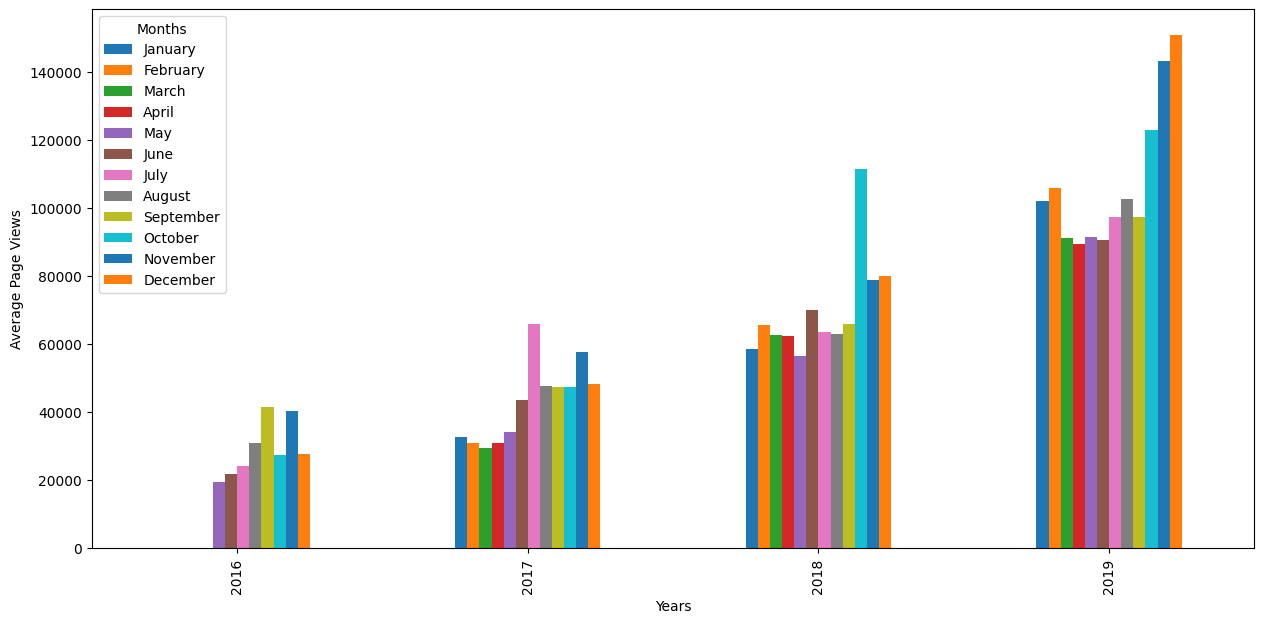

In [7]:
draw_bar_plot()

In [8]:
# 5. Create a draw_box_plot function
def draw_box_plot():
    # Prepare data for box plots (this part is provided in the boilerplate)
    df_box = df.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = [d.year for d in df_box.date]
    df_box['month'] = [d.strftime('%b') for d in df_box.date]

    # Set up the matplotlib figure layout (1 row, 2 columns)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

    # Draw Year-wise Box Plot (Trend)
    sns.boxplot(x='year', y='value', data=df_box, ax=axes[0])
    axes[0].set_title('Year-wise Box Plot (Trend)')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Page Views')

    # Ensure month labels on the bottom start at Jan
    months_short_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Draw Month-wise Box Plot (Seasonality)
    sns.boxplot(x='month', y='value', data=df_box, ax=axes[1], order=months_short_order)
    axes[1].set_title('Month-wise Box Plot (Seasonality)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Page Views')

    # Save image and return fig (don't change this part)
    fig.savefig('box_plot.png')
    return fig

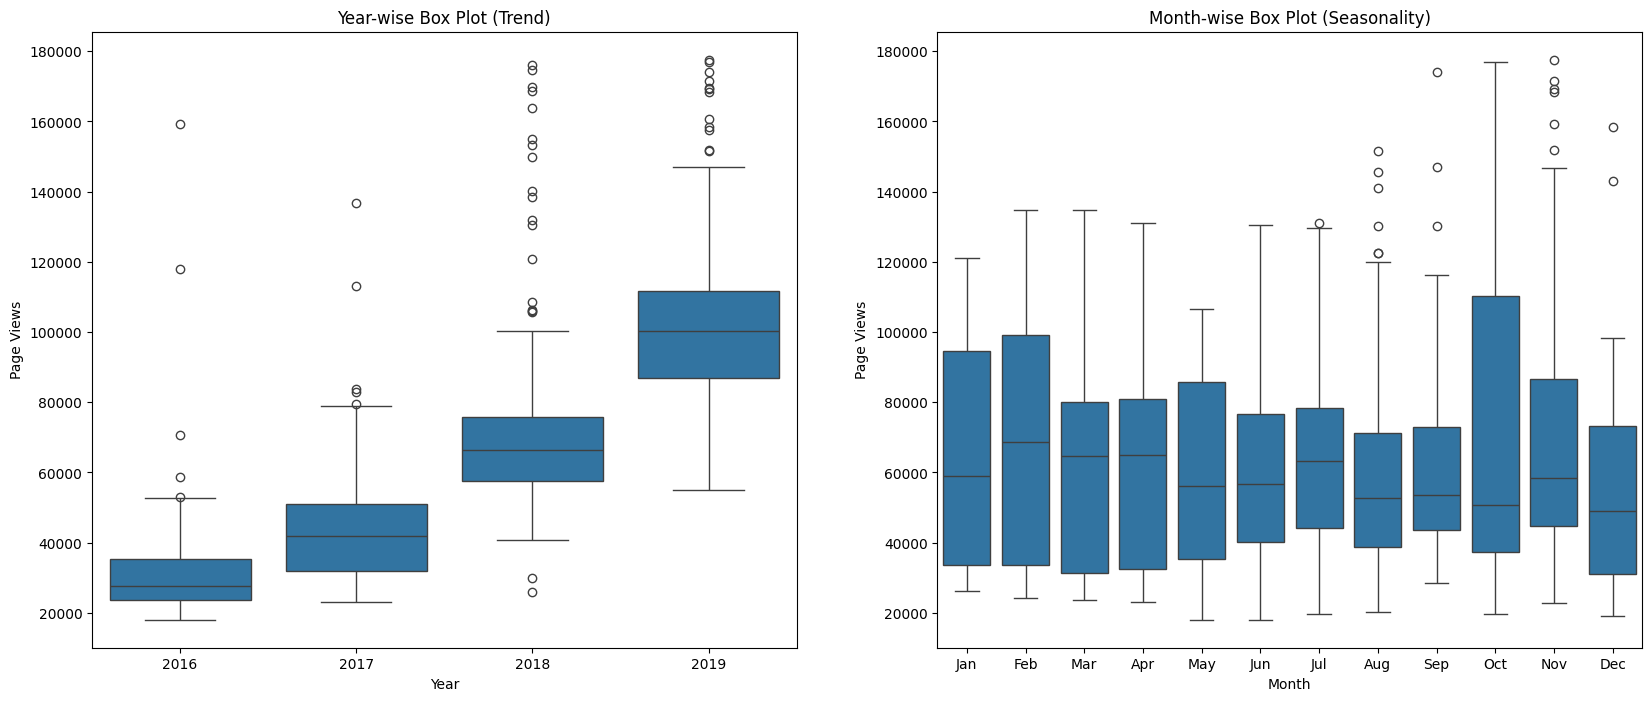

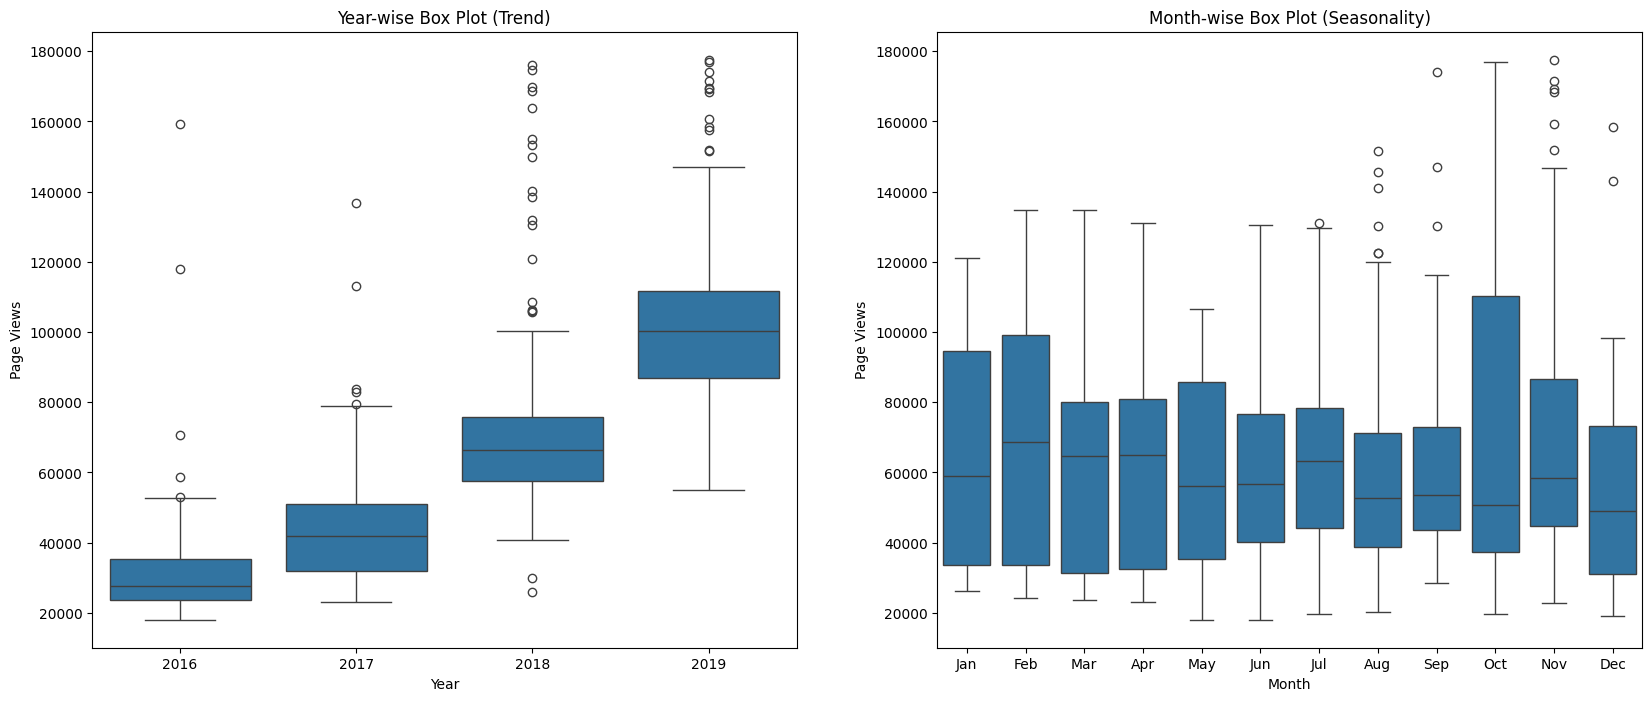

In [9]:
draw_box_plot()